Đang tải dữ liệu và nạp mô hình...


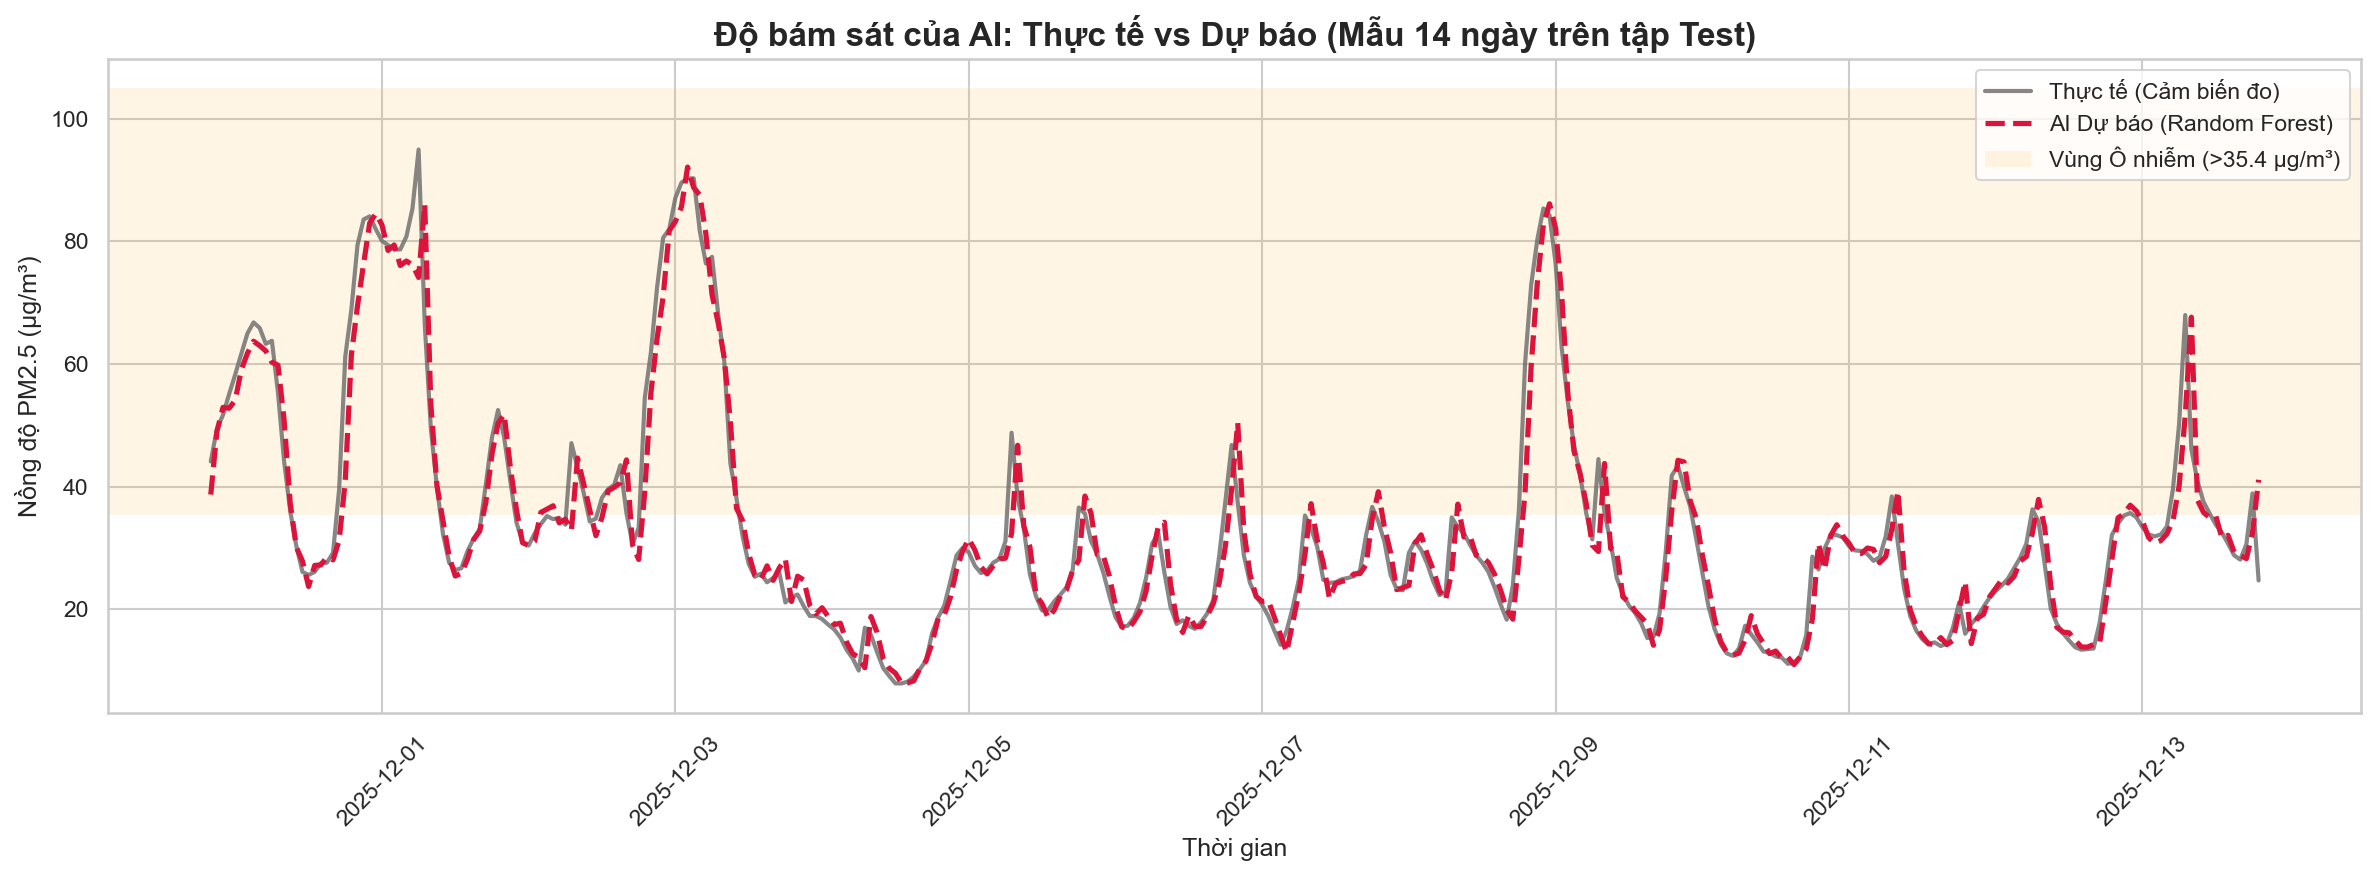

Đã lưu Biểu đồ tại: ../reports/figures/06_actual_vs_predicted.png


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# CẤU HÌNH ĐƯỜNG DẪN VÀ GIAO DIỆN
PATH_INPUT = "../data/03_processed/pm25_features_ready.csv"
PATH_MODEL = "../models/random_forest_pm25.pkl"
DIR_FIGURES = "../reports/figures/"
os.makedirs(DIR_FIGURES, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

print("Đang tải dữ liệu và nạp mô hình...")

# ĐỌC DỮ LIỆU & CẮT TẬP TEST
df = pd.read_csv(PATH_INPUT)
df['datetime'] = pd.to_datetime(df['datetime'])

X = df.drop(columns=['datetime', 'pm25'])
y = df['pm25']

# Lấy 15% dữ liệu cuối cùng làm tập Test
idx_val_end = int(len(df) * 0.85)
X_test = X.iloc[idx_val_end:]
y_test = y.iloc[idx_val_end:]
dates_test = df['datetime'].iloc[idx_val_end:].reset_index(drop=True)

# CHẠY AI DỰ BÁO
# Nạp lại mô hình đã lưu
rf_model_main = joblib.load(PATH_MODEL)

# Tiến hành dự báo trên tập Test
y_pred_test = rf_model_main.predict(X_test)

# VẼ BIỂU ĐỒ (MẪU 14 NGÀY)
# Cắt lấy đúng 14 ngày = 14 * 24 = 336 giờ
HOURS_TO_SHOW = 336 
y_test_plot = y_test.iloc[:HOURS_TO_SHOW].values
y_pred_plot = y_pred_test[:HOURS_TO_SHOW]
dates_plot = dates_test[:HOURS_TO_SHOW]

plt.figure(figsize=(16, 6))

# Đường 1: Thực tế
plt.plot(dates_plot, y_test_plot, label='Thực tế (Cảm biến đo)', color='dimgray', alpha=0.8, linewidth=2)

# Đường 2: AI Dự báo
plt.plot(dates_plot, y_pred_plot, label='AI Dự báo (Random Forest)', color='crimson', linestyle='--', linewidth=2.5)

# Tùy chọn thêm: Đánh dấu dải băng màu cam cho các vùng ô nhiễm (AQI > 35.4)
ymax = max(max(y_test_plot), max(y_pred_plot)) + 10
plt.axhspan(35.4, ymax, facecolor='orange', alpha=0.1, label='Vùng Ô nhiễm (>35.4 µg/m³)')

# Trang trí biểu đồ
plt.title('Độ bám sát của AI: Thực tế vs Dự báo (Mẫu 14 ngày trên tập Test)', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Nồng độ PM2.5 (µg/m³)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()

# Lưu và hiển thị
path_fig_actual_pred = os.path.join(DIR_FIGURES, "06_actual_vs_predicted.png")
plt.savefig(path_fig_actual_pred)
plt.show()

print(f"Đã lưu Biểu đồ tại: {path_fig_actual_pred}")

Các biến bị loại bỏ để phân tích: ['pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag24', 'pm25_roll3', 'pm25_roll6', 'pm25_roll12', 'pm25_roll24']
Đang ép AI phải tư duy dựa trên Giao thông và Thời tiết...


C:\Users\Tien Loi\AppData\Local\Temp\ipykernel_4172\2280735037.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance_explain, palette='magma')


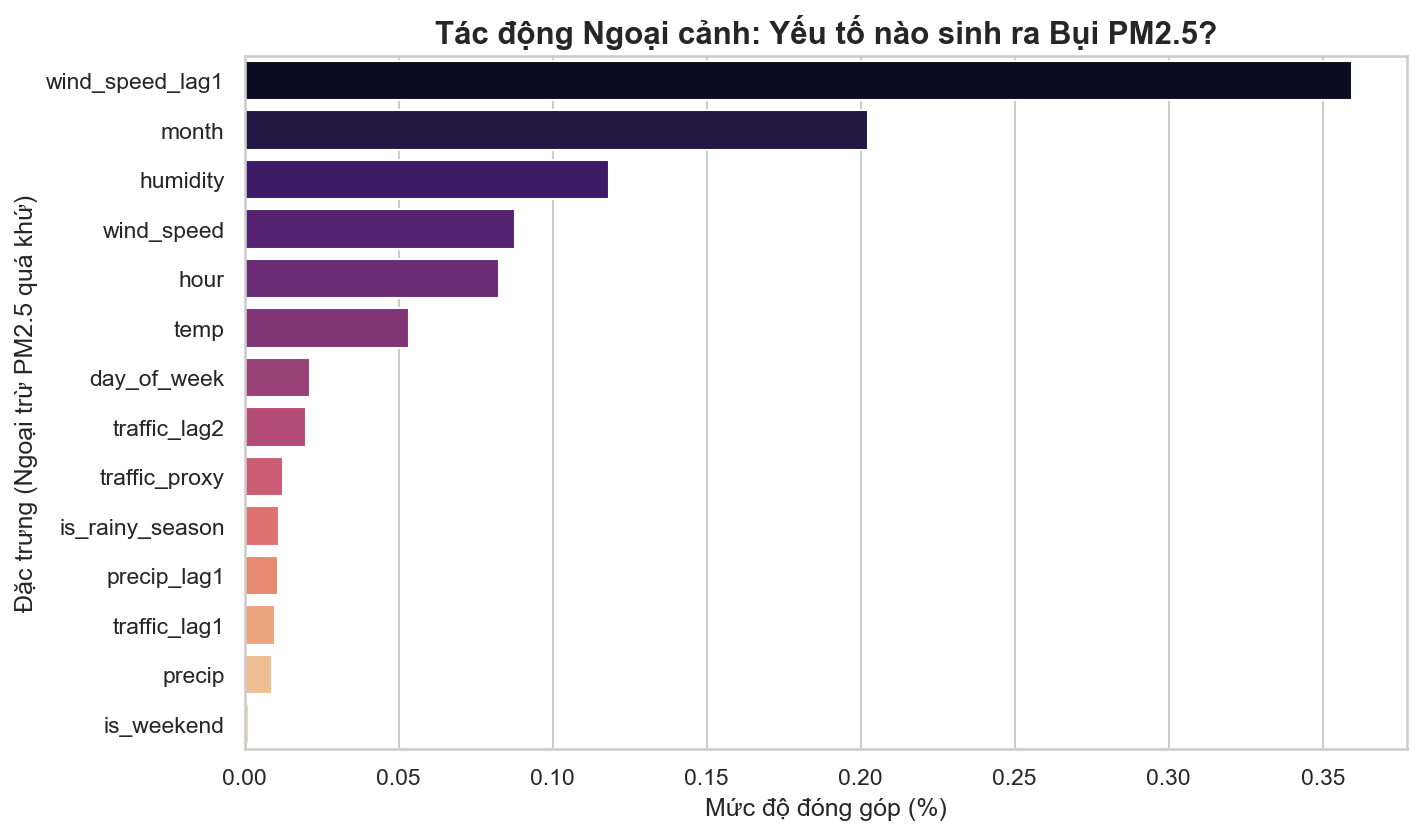


Đã lưu Biểu đồ Bản chất thực sự tại: ../reports/figures/05_feature_importance_external.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import os

DIR_FIGURES = "../reports/figures/"
os.makedirs(DIR_FIGURES, exist_ok=True)

# Khai báo x, y
idx_train_end = int(len(X) * 0.70)
X_train = X.iloc[:idx_train_end]
y_train = y.iloc[:idx_train_end]
# -------------------------------

# Tìm tất cả các cột liên quan đến quá khứ của PM2.5 (lag và roll)
autoregressive_cols = [col for col in X_train.columns if 'pm25_' in col]
print(f"Các biến bị loại bỏ để phân tích: {autoregressive_cols}")

# Tạo tập dữ liệu "Mù quá khứ" (Chỉ còn Thời gian, Giao thông, Thời tiết)
X_train_explain = X_train.drop(columns=autoregressive_cols)
X_test_explain = X_test.drop(columns=autoregressive_cols)

# 3. Huấn luyện một mô hình AI
print("Đang ép AI phải tư duy dựa trên Giao thông và Thời tiết...")
rf_explain = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_explain.fit(X_train_explain, y_train)

# Trích xuất mức độ quan trọng (Feature Importance) mới
importances_explain = rf_explain.feature_importances_
features_explain = X_train_explain.columns

df_importance_explain = pd.DataFrame({'Feature': features_explain, 'Importance': importances_explain})
df_importance_explain = df_importance_explain.sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance_explain, palette='magma')

plt.title('Tác động Ngoại cảnh: Yếu tố nào sinh ra Bụi PM2.5?', fontsize=15, fontweight='bold')
plt.xlabel('Mức độ đóng góp (%)')
plt.ylabel('Đặc trưng (Ngoại trừ PM2.5 quá khứ)')

path_fig_explain = os.path.join(DIR_FIGURES, "05_feature_importance_external.png")
plt.savefig(path_fig_explain, bbox_inches='tight')
plt.show()

print(f"\nĐã lưu Biểu đồ Bản chất thực sự tại: {path_fig_explain}")